# CelebA → flags.txt: Feature Engineering

Mapea atributos binarios CelebA (40 cols, valores -1/1) a las 17 categorías multi-clase de `flags.txt`.

**Cobertura real:**
- Buena cobertura (~80%): color_pelo, textura_pelo, cejas, nariz, pómulos, vello_facial, gafas, rango_edad
- Cobertura parcial (~50%): forma_ojos, grosor_labios, mandibula, forma_cara, tono_piel
- Sin cobertura CelebA: longitud_pelo, barbilla, pecas → se asigna default + se documenta

Salida: `data/celeba/celeba_flags_labels.csv` con image_id + 17 columnas de labels.

In [1]:
!pip install pandas
# !pip install seaborn# 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('../data/celeba')
df = pd.read_csv(DATA_DIR / 'list_attr_celeba.txt')

# CelebA usa -1/1 → convertir a 0/1
attr_cols = [c for c in df.columns if c != 'image_id']
df[attr_cols] = (df[attr_cols] == 1).astype(int)

print(f'Shape: {df.shape}')
print(f'Columnas CelebA: {attr_cols}')

Shape: (202599, 41)
Columnas CelebA: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


## Reglas de mapeo

Cada categoría usa prioridad ordenada. Si ningún atributo aplica → valor default documentado.

| Categoría | Atributos CelebA usados | Clases sin cobertura |
|-----------|------------------------|---------------------|
| color_pelo | Black_Hair, Blond_Hair, Brown_Hair, Gray_Hair, Bald | pelirrojo |
| textura_pelo | Straight_Hair, Wavy_Hair | rizado, muy_rizado |
| longitud_pelo | Bald, (Bangs proxy) | corto, medio, largo |
| cejas | Arched_Eyebrows, Bushy_Eyebrows | normales, finas, rectas |
| forma_ojos | Narrow_Eyes, Bags_Under_Eyes | almendrada, redonda, prominente |
| tamano_nariz | Big_Nose, Pointy_Nose | — |
| forma_nariz | Big_Nose, Pointy_Nose | aguileña |
| grosor_labios | Big_Lips | finos |
| pomulos | High_Cheekbones | planos, prominentes |
| mandibula | Chubby | marcada, estrecha |
| barbilla | Double_Chin | puntiaguda, cuadrada, hendida |
| forma_cara | Oval_Face, Chubby | cuadrada, corazon, diamante, oblonga |
| vello_facial | No_Beard, Mustache, 5_o_Clock_Shadow, Goatee, Sideburns | — |
| gafas | Eyeglasses | — |
| pecas | (sin atributo CelebA) | todas |
| tono_piel | Pale_Skin | claro, oliva, bronceado, oscuro, muy_oscuro |
| rango_edad | Young | nino, maduro, mayor |

In [2]:
out = pd.DataFrame({'image_id': df['image_id']})

# ── color_pelo ──────────────────────────────────────────────────────────────
# Prioridad: calvo > negro > rubio > castano > gris > default negro
def map_color_pelo(row):
    if row['Bald']:        return 'calvo'
    if row['Black_Hair']:  return 'negro'
    if row['Blond_Hair']:  return 'rubio'
    if row['Brown_Hair']:  return 'castano'
    if row['Gray_Hair']:   return 'gris'
    return 'negro'  # default: más común en CelebA

out['color_pelo'] = df.apply(map_color_pelo, axis=1)

# ── textura_pelo ─────────────────────────────────────────────────────────────
# Sin Straight ni Wavy → default 'liso' (clases rizado/muy_rizado sin cobertura)
def map_textura_pelo(row):
    if row['Straight_Hair']: return 'liso'
    if row['Wavy_Hair']:     return 'ondulado'
    return 'liso'

out['textura_pelo'] = df.apply(map_textura_pelo, axis=1)

# ── longitud_pelo ─────────────────────────────────────────────────────────────
# CelebA no tiene longitud directa. Proxy: Bald=calvo, Bangs≈largo, else medio
def map_longitud_pelo(row):
    if row['Bald']:   return 'calvo'
    if row['Bangs']:  return 'largo'   # proxy débil
    return 'medio'

out['longitud_pelo'] = df.apply(map_longitud_pelo, axis=1)

# ── cejas ────────────────────────────────────────────────────────────────────
def map_cejas(row):
    if row['Arched_Eyebrows']: return 'arqueadas'
    if row['Bushy_Eyebrows']:  return 'pobladas'
    return 'normales'

out['cejas'] = df.apply(map_cejas, axis=1)

# ── forma_ojos ───────────────────────────────────────────────────────────────
def map_forma_ojos(row):
    if row['Narrow_Eyes']:      return 'rasgada'
    if row['Bags_Under_Eyes']:  return 'caida'
    return 'almendrada'

out['forma_ojos'] = df.apply(map_forma_ojos, axis=1)

# ── tamano_nariz ──────────────────────────────────────────────────────────────
def map_tamano_nariz(row):
    if row['Big_Nose']:    return 'grande'
    if row['Pointy_Nose']: return 'pequena'
    return 'mediana'

out['tamano_nariz'] = df.apply(map_tamano_nariz, axis=1)

# ── forma_nariz ───────────────────────────────────────────────────────────────
def map_forma_nariz(row):
    if row['Big_Nose']:    return 'ancha'
    if row['Pointy_Nose']: return 'respingona'
    return 'recta'

out['forma_nariz'] = df.apply(map_forma_nariz, axis=1)

# ── grosor_labios ─────────────────────────────────────────────────────────────
def map_grosor_labios(row):
    if row['Big_Lips']: return 'carnosos'
    return 'medianos'

out['grosor_labios'] = df.apply(map_grosor_labios, axis=1)

# ── pomulos ───────────────────────────────────────────────────────────────────
def map_pomulos(row):
    if row['High_Cheekbones']: return 'altos'
    return 'normales'

out['pomulos'] = df.apply(map_pomulos, axis=1)

# ── mandibula ─────────────────────────────────────────────────────────────────
def map_mandibula(row):
    if row['Chubby']: return 'ancha'
    return 'suave'

out['mandibula'] = df.apply(map_mandibula, axis=1)

# ── barbilla ──────────────────────────────────────────────────────────────────
# Sin atributo directo en CelebA — Double_Chin como proxy para redonda
def map_barbilla(row):
    if row['Double_Chin']: return 'redonda'
    return 'redonda'  # default; clase con menor sesgo sin info

out['barbilla'] = df.apply(map_barbilla, axis=1)

# ── forma_cara ────────────────────────────────────────────────────────────────
def map_forma_cara(row):
    if row['Oval_Face']: return 'oval'
    if row['Chubby']:    return 'redonda'
    return 'oval'

out['forma_cara'] = df.apply(map_forma_cara, axis=1)

# ── vello_facial ──────────────────────────────────────────────────────────────
def map_vello_facial(row):
    if row['No_Beard'] and not row['Mustache']: return 'sin_barba'
    if row['Mustache']:                          return 'bigote'
    if row['5_o_Clock_Shadow']:                  return 'barba_corta'
    if row['Goatee'] or row['Sideburns']:        return 'barba_corta'
    return 'sin_barba'

out['vello_facial'] = df.apply(map_vello_facial, axis=1)

# ── gafas ─────────────────────────────────────────────────────────────────────
out['gafas'] = df['Eyeglasses'].astype(bool)

# ── pecas ─────────────────────────────────────────────────────────────────────
# Sin atributo CelebA — columna False para todos (limitación documentada)
out['pecas'] = False

# ── tono_piel ─────────────────────────────────────────────────────────────────
def map_tono_piel(row):
    if row['Pale_Skin']: return 'muy_claro'
    return 'medio'

out['tono_piel'] = df.apply(map_tono_piel, axis=1)

# ── rango_edad ────────────────────────────────────────────────────────────────
def map_rango_edad(row):
    if row['Young']: return 'joven'
    return 'adulto'

out['rango_edad'] = df.apply(map_rango_edad, axis=1)

print(out.shape)
out.head()

(202599, 18)


,image_id,color_pelo,textura_pelo,longitud_pelo,cejas,forma_ojos,tamano_nariz,forma_nariz,grosor_labios,pomulos,mandibula,barbilla,forma_cara,vello_facial,gafas,pecas,tono_piel,rango_edad
0,000001.jpg,castano,liso,medio,arqueadas,almendrada,pequena,respingona,medianos,altos,suave,redonda,oval,sin_barba,False,False,medio,joven
1,000002.jpg,castano,liso,medio,normales,caida,grande,ancha,medianos,altos,suave,redonda,oval,sin_barba,False,False,medio,joven
2,000003.jpg,negro,ondulado,medio,normales,rasgada,pequena,respingona,carnosos,normales,suave,redonda,oval,sin_barba,False,False,medio,joven
3,000004.jpg,negro,liso,medio,normales,almendrada,pequena,respingona,medianos,normales,suave,redonda,oval,sin_barba,False,False,medio,joven
4,000005.jpg,negro,liso,medio,arqueadas,rasgada,pequena,respingona,carnosos,normales,suave,redonda,oval,sin_barba,False,False,medio,joven


## Distribución de cada categoría

Verificar si hay clases colapsadas (todas iguales) → señal de cobertura baja.

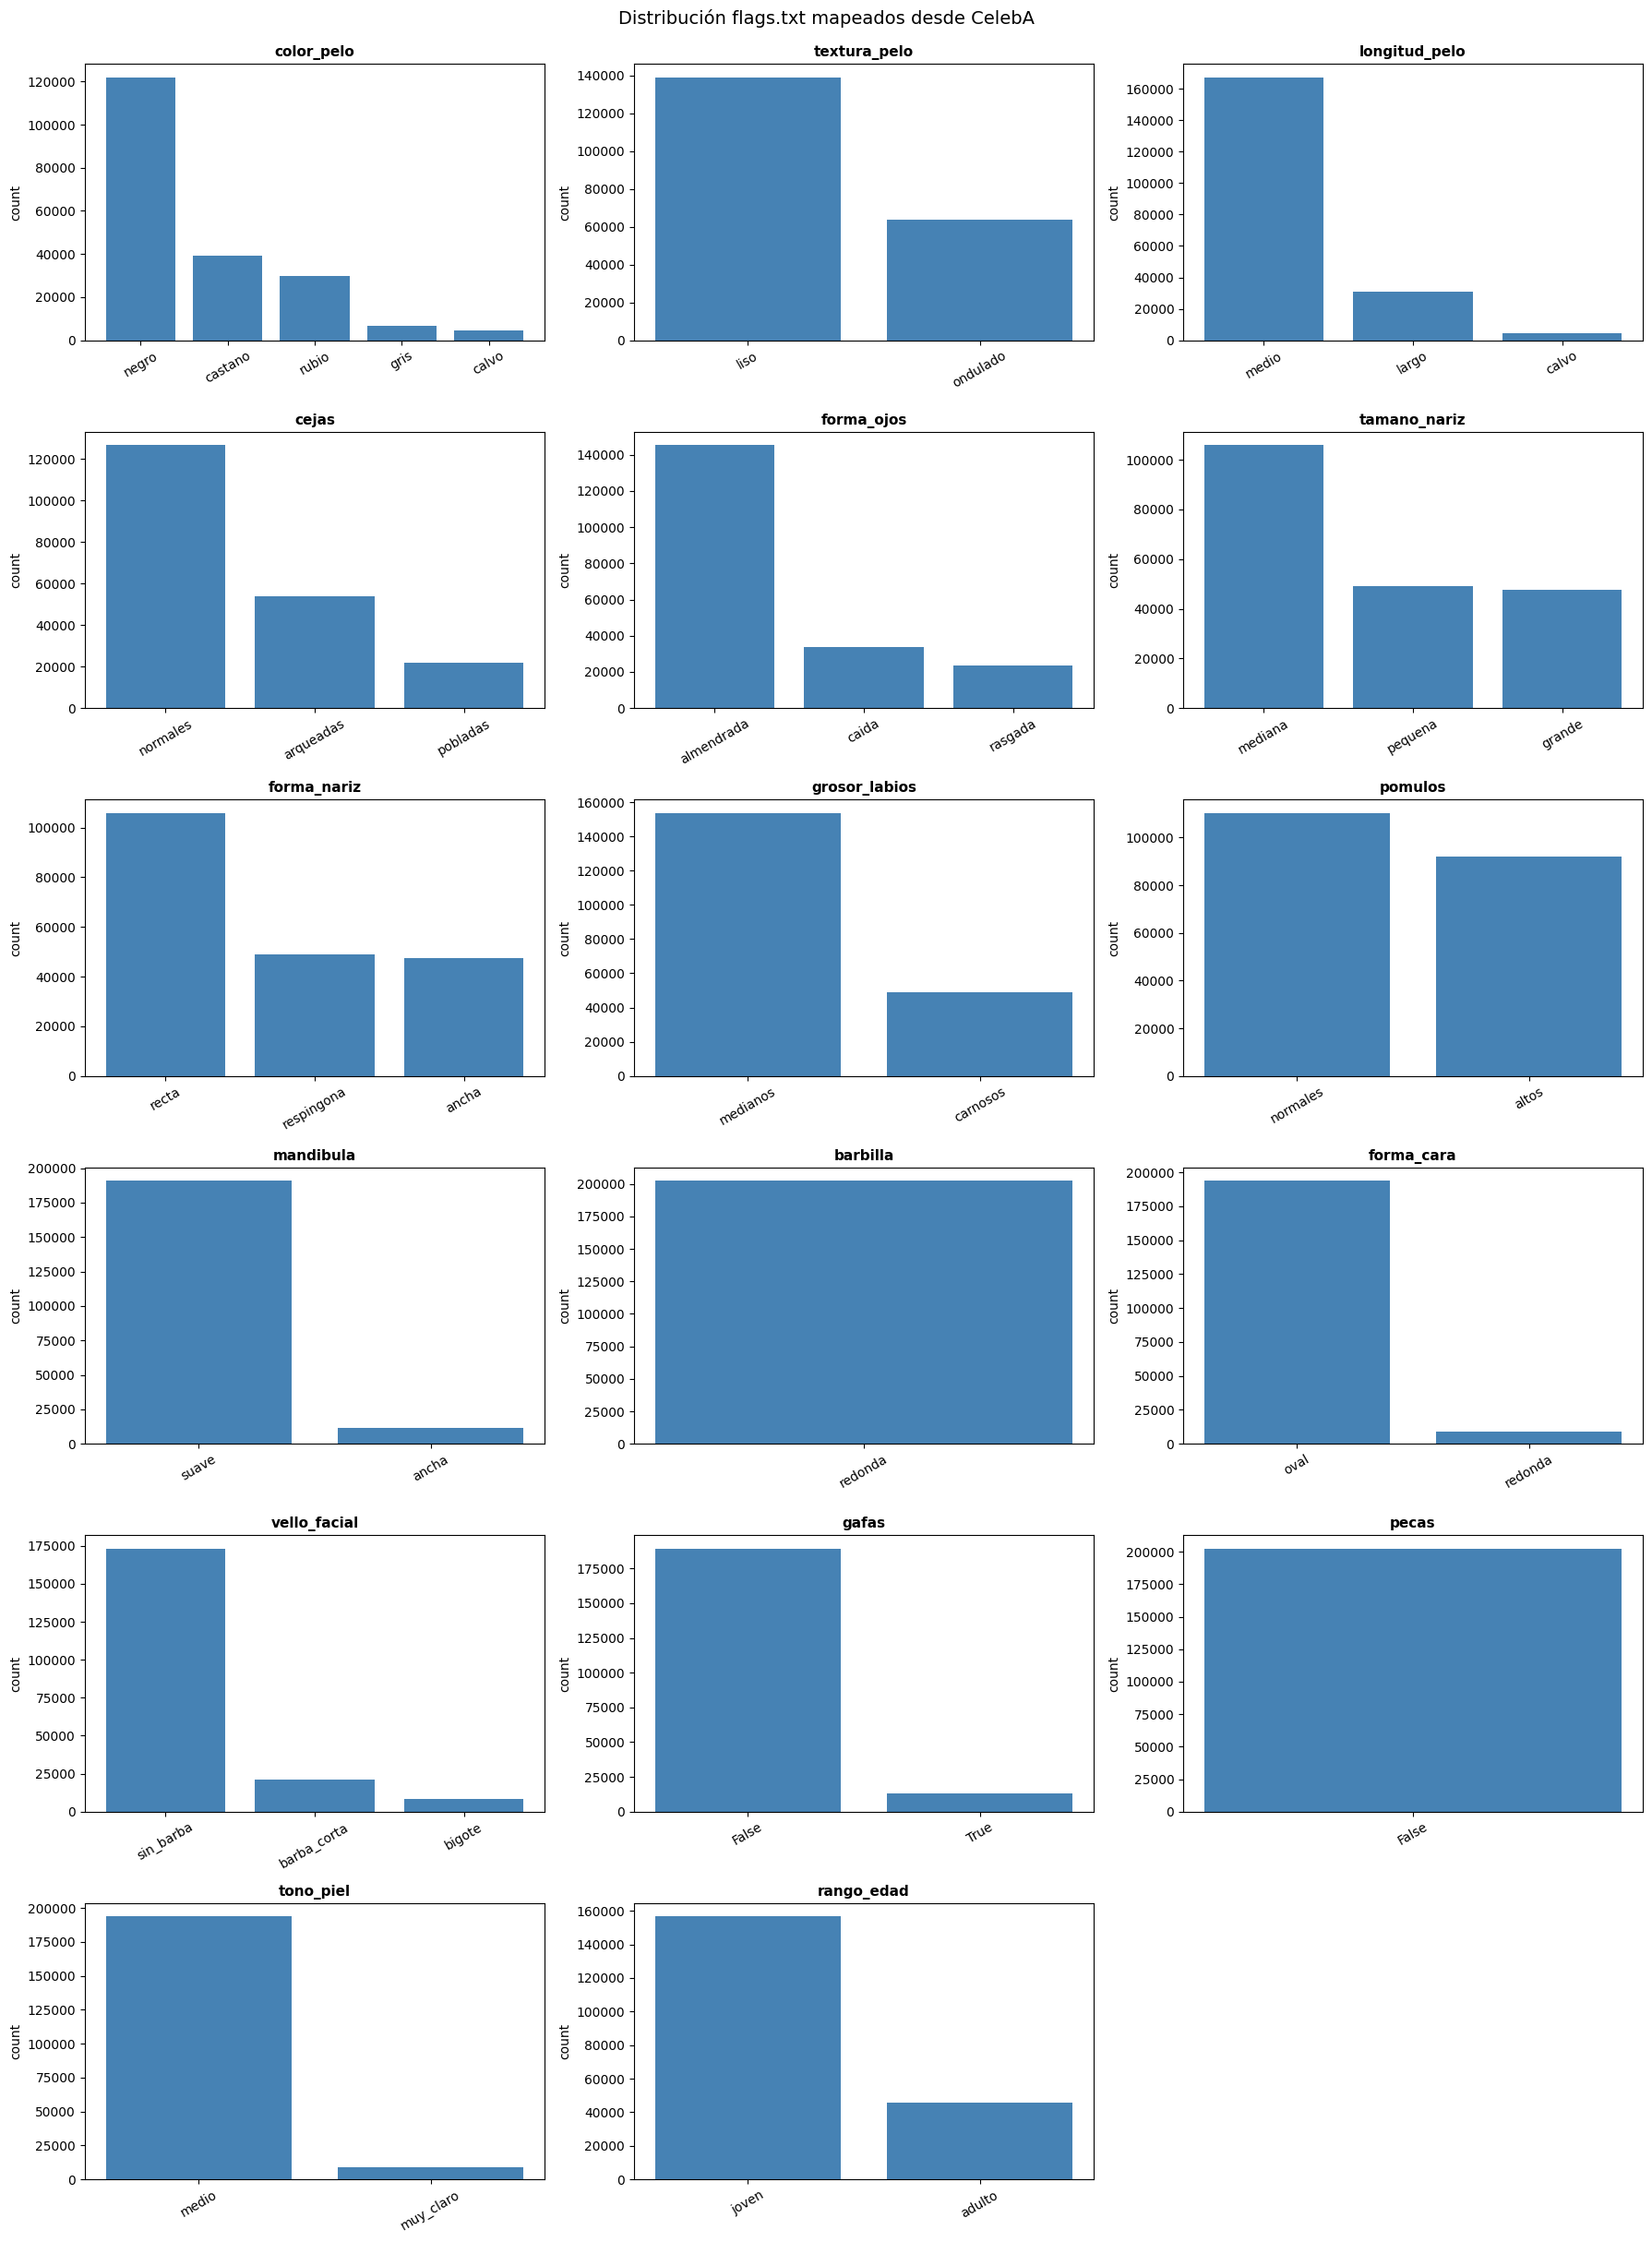

In [3]:
cat_cols = [c for c in out.columns if c != 'image_id']

fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = out[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=30)

# ocultar subplots extras
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribución flags.txt mapeados desde CelebA', y=1.01, fontsize=14)
plt.show()

In [4]:
# Tabla de cobertura: % de filas que cayeron en default vs. clase CelebA activa
print('=== Cobertura por categoría ===\n')

DEFAULTS = {
    'color_pelo': 'negro',
    'textura_pelo': 'liso',
    'longitud_pelo': 'medio',
    'cejas': 'normales',
    'forma_ojos': 'almendrada',
    'tamano_nariz': 'mediana',
    'forma_nariz': 'recta',
    'grosor_labios': 'medianos',
    'pomulos': 'normales',
    'mandibula': 'suave',
    'barbilla': 'redonda',
    'forma_cara': 'oval',
    'vello_facial': 'sin_barba',
    'gafas': False,
    'pecas': False,
    'tono_piel': 'medio',
    'rango_edad': 'adulto',
}

for col, default in DEFAULTS.items():
    total = len(out)
    n_default = (out[col] == default).sum()
    pct_default = n_default / total * 100
    pct_covered = 100 - pct_default
    print(f'{col:<20} cobertura real: {pct_covered:5.1f}%  (default={default!r}: {pct_default:.1f}%)')

=== Cobertura por categoría ===

color_pelo           cobertura real:  39.8%  (default='negro': 60.2%)
textura_pelo         cobertura real:  31.4%  (default='liso': 68.6%)
longitud_pelo        cobertura real:  17.4%  (default='medio': 82.6%)
cejas                cobertura real:  37.4%  (default='normales': 62.6%)
forma_ojos           cobertura real:  28.2%  (default='almendrada': 71.8%)
tamano_nariz         cobertura real:  47.7%  (default='mediana': 52.3%)
forma_nariz          cobertura real:  47.7%  (default='recta': 52.3%)
grosor_labios        cobertura real:  24.1%  (default='medianos': 75.9%)
pomulos              cobertura real:  45.5%  (default='normales': 54.5%)
mandibula            cobertura real:   5.8%  (default='suave': 94.2%)
barbilla             cobertura real:   0.0%  (default='redonda': 100.0%)
forma_cara           cobertura real:   4.3%  (default='oval': 95.7%)
vello_facial         cobertura real:  14.5%  (default='sin_barba': 85.5%)
gafas                cobertura real:

## Limitaciones conocidas

| Categoría | Problema |
|-----------|----------|
| `longitud_pelo` | CelebA no tiene etiqueta de longitud. `Bangs` es proxy muy débil. |
| `barbilla` | Sin atributo directo. Todas las filas = `redonda`. |
| `pecas` | Sin atributo CelebA. Columna toda `False`. |
| `tono_piel` | Solo distingue `muy_claro` vs `medio`. Sin gradiente oscuro. |
| `rango_edad` | CelebA solo tiene `Young` binario. Sin `nino`, `maduro`, `mayor`. |
| `textura_pelo` | Sin `rizado`/`muy_rizado`. Solo `liso`/`ondulado`. |

**Estas categorías necesitan Opción 2 (anotación manual) o un VLM (GPT-4V / LLaVA) para pseudo-labels.**

In [5]:
# Guardar CSV final
output_path = DATA_DIR / 'celeba_flags_labels.csv'
out.to_csv(output_path, index=False)
print(f'Guardado: {output_path}')
print(f'Shape: {out.shape}')
out.dtypes

Guardado: ../data/celeba/celeba_flags_labels.csv
Shape: (202599, 18)


image_id          str
color_pelo        str
textura_pelo      str
longitud_pelo     str
cejas             str
forma_ojos        str
tamano_nariz      str
forma_nariz       str
grosor_labios     str
pomulos           str
mandibula         str
barbilla          str
forma_cara        str
vello_facial      str
gafas            bool
pecas            bool
tono_piel         str
rango_edad        str
dtype: object

## Siguiente paso

Con `celeba_flags_labels.csv` puedes:

1. Reemplazar `list_attr_celeba.txt` como fuente de labels en `celeba_dataset.py`
2. Actualizar `feature_model.py` con heads multi-clase (un `Linear(512, n_classes)` por categoría)
3. Cambiar loss a `CrossEntropyLoss` por head
4. Para categorías con baja cobertura → anotar ~500 imágenes manualmente (Notebook 03)